# Final Model Comparison and Selection

This notebook combines the results obtained from all previously implemented machine learning, deep learning, and transformer-based models for SMS Spam Classification.

The objective of this notebook is to:

- Consolidate performance metrics from all experiments
- Compare models using Accuracy, Precision, Recall, and F1 Score
- Rank models according to classification performance
- Identify the best-performing model
- Provide final conclusions regarding model suitability for SMS spam detection

The models evaluated include:

1. Logistic Regression
2. Naive Bayes
3. Linear SVM
4. LSTM
5. BiLSTM
6. DistilBERT
7. BERT

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

## Loading Experimental Results

The performance results generated from previous notebooks are loaded into this notebook.

The results are divided into three categories:

- Traditional Machine Learning Models
- Deep Learning Models
- Transformer-Based Models

Each result file contains Accuracy, Precision, Recall, and F1 Score obtained on the test dataset.

In [2]:
traditional_results = pd.read_csv(
    "../results/traditional_ml_results.csv"
)

traditional_results

,Model,Accuracy,Precision,Recall,F1
0,Linear SVM,0.983226,0.967033,0.897959,0.931217
1,Naive Bayes,0.963871,0.986111,0.724490,0.835294
2,Logistic Regression,0.948387,1.000000,0.591837,0.743590


In [3]:
deep_learning_results = pd.read_csv(
    "../results/deep_learning_results.csv"
)

deep_learning_results

,Model,Accuracy,Precision,Recall,F1
0,LSTM,0.980645,0.956044,0.887755,0.920635
1,BiLSTM,0.972903,0.952941,0.826531,0.885246


In [4]:
transformer_results = pd.read_csv(
    "../results/transformer_results.csv"
)

transformer_results

,Model,Accuracy,Precision,Recall,F1
0,BERT,0.975484,0.898990,0.908163,0.903553
1,DistilBERT,0.972903,0.846847,0.959184,0.899522


In [5]:
all_results = pd.concat(

    [

        traditional_results,

        deep_learning_results,

        transformer_results

    ],

    ignore_index=True

)

all_results

,Model,Accuracy,Precision,Recall,F1
0,Linear SVM,0.983226,0.967033,0.897959,0.931217
1,Naive Bayes,0.963871,0.986111,0.724490,0.835294
2,Logistic Regression,0.948387,1.000000,0.591837,0.743590
3,LSTM,0.980645,0.956044,0.887755,0.920635
4,BiLSTM,0.972903,0.952941,0.826531,0.885246
5,BERT,0.975484,0.898990,0.908163,0.903553
6,DistilBERT,0.972903,0.846847,0.959184,0.899522


In [6]:
all_results = all_results.sort_values(

    by="F1",

    ascending=False

)

all_results

,Model,Accuracy,Precision,Recall,F1
0,Linear SVM,0.983226,0.967033,0.897959,0.931217
3,LSTM,0.980645,0.956044,0.887755,0.920635
5,BERT,0.975484,0.898990,0.908163,0.903553
6,DistilBERT,0.972903,0.846847,0.959184,0.899522
4,BiLSTM,0.972903,0.952941,0.826531,0.885246
1,Naive Bayes,0.963871,0.986111,0.724490,0.835294
2,Logistic Regression,0.948387,1.000000,0.591837,0.743590


## Ranked Performance Results

The models have been sorted in descending order of F1 Score.

Higher F1 Scores indicate better balance between spam detection capability (Recall) and prediction reliability (Precision).

The ranking allows direct comparison of model effectiveness on the SMS Spam Collection dataset.

In [7]:
all_results.to_csv(

    "../results/final_model_comparison.csv",

    index=False

)

## Comparison Based on F1 Score

This visualization compares all models using F1 Score.

Since F1 Score combines both Precision and Recall, it serves as the primary evaluation metric for identifying the most suitable spam classification model.

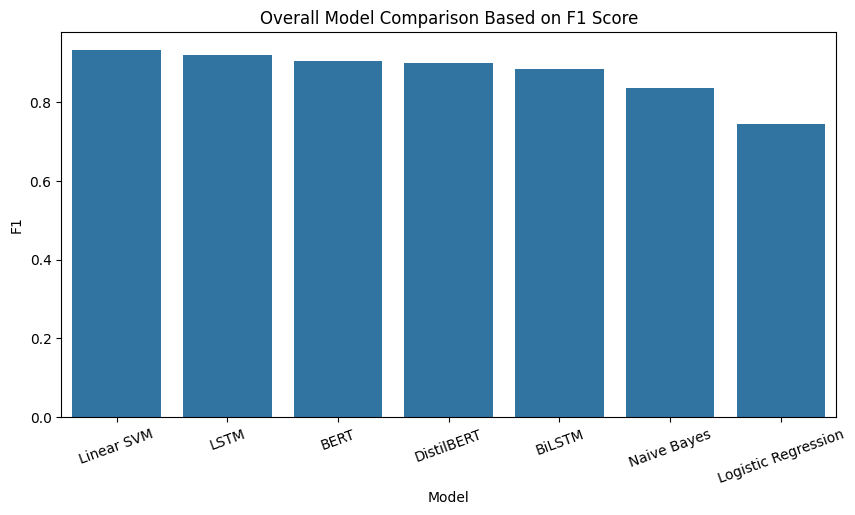

In [8]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=all_results,

    x="Model",

    y="F1"

)

plt.title(

    "Overall Model Comparison Based on F1 Score"

)

plt.xticks(rotation=20)

plt.savefig(

    "../results/figures/final_model_comparison.png",

    bbox_inches="tight"

)

plt.show()

## Comparison Based on Accuracy

This visualization compares models using Accuracy.

Although most models achieve very high accuracy values, Accuracy alone may not adequately represent performance on imbalanced datasets.

Therefore, Accuracy is analyzed alongside Precision, Recall, and F1 Score.

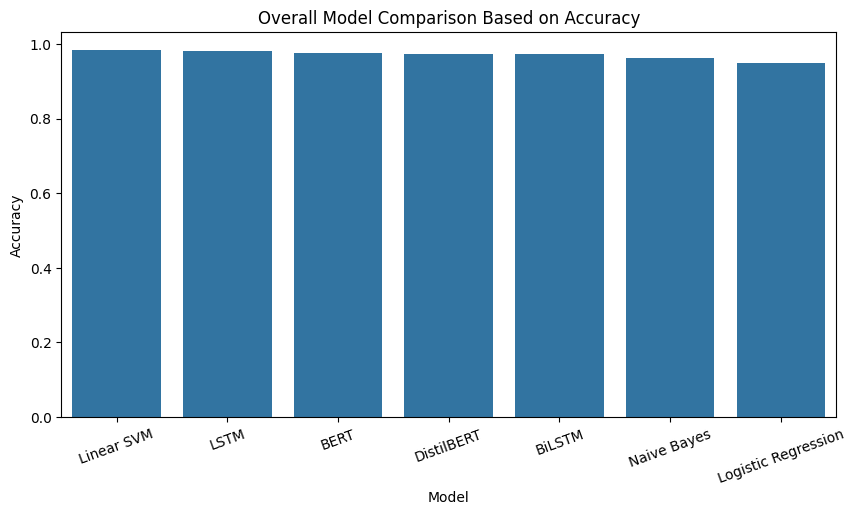

In [9]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=all_results,

    x="Model",

    y="Accuracy"

)

plt.title(

    "Overall Model Comparison Based on Accuracy"

)

plt.xticks(rotation=20)

plt.savefig(

    "../results/figures/final_accuracy_comparison.png",

    bbox_inches="tight"

)

plt.show()

## Best Model Identification

The highest-ranked model is selected using F1 Score.

This model represents the best trade-off between detecting spam messages and minimizing false alarms.

The selected model can be considered the most suitable candidate for deployment in real-world SMS spam filtering applications.

In [10]:
top_model = all_results.iloc[0]

print("Best Model:")
print(top_model)

Best Model:
Model        Linear SVM
Accuracy       0.983226
Precision      0.967033
Recall         0.897959
F1             0.931217
Name: 0, dtype: object


## Discussion of Results

Several interesting observations can be made from the experimental results:

### Linear SVM

Linear SVM achieved the highest F1 Score of 0.9312 and emerged as the best-performing model.

### LSTM

LSTM achieved strong performance with an F1 Score of 0.9206, demonstrating the effectiveness of sequential deep learning architectures for text classification.

### BERT

BERT achieved an F1 Score of 0.9036 and demonstrated strong contextual understanding capabilities.

### DistilBERT

DistilBERT achieved competitive performance while requiring fewer computational resources than BERT.

### BiLSTM

BiLSTM performed slightly worse than LSTM despite having access to both forward and backward contextual information.

### Naive Bayes

Naive Bayes delivered reasonable performance despite its simplicity and low computational cost.

### Logistic Regression

Logistic Regression achieved the lowest F1 Score due to relatively poor recall performance on spam messages.

In [12]:
all_results
all_results.to_csv(
    "../results/final_model_comparison.csv",
    index=False
)

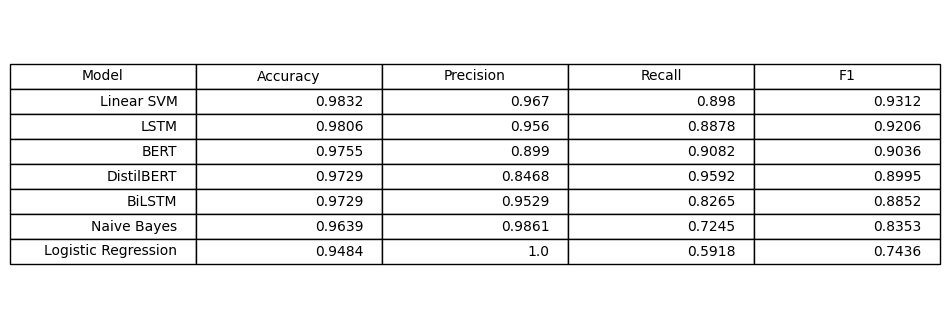

In [13]:
plt.figure(figsize=(10,4))

plt.axis("off")

table = plt.table(
    cellText=all_results.round(4).values,
    colLabels=all_results.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.savefig(
    "../results/figures/final_results_table.png",
    bbox_inches="tight"
)

plt.show()

## Final Conclusion

A total of seven models were implemented and evaluated for SMS Spam Classification.

The models included:

- Logistic Regression
- Naive Bayes
- Linear SVM
- LSTM
- BiLSTM
- DistilBERT
- BERT

Performance evaluation was conducted using Accuracy, Precision, Recall, and F1 Score.

The final ranking based on F1 Score was:

1. Linear SVM (0.9312)
2. LSTM (0.9206)
3. BERT (0.9036)
4. DistilBERT (0.8995)
5. BiLSTM (0.8852)
6. Naive Bayes (0.8353)
7. Logistic Regression (0.7436)

The experimental results indicate that model performance is strongly influenced by the characteristics of the dataset. The SMS Spam Collection dataset consists of relatively short text messages and contains a limited number of training samples compared to the large-scale corpora typically required for deep learning and transformer-based models to realize their full potential.

Although advanced architectures such as LSTM, BiLSTM, BERT, and DistilBERT were successfully implemented and evaluated, they did not provide a significant performance advantage over the traditional machine learning approaches in this specific setting. The combination of TF-IDF feature extraction and Linear Support Vector Machine (SVM) achieved the highest overall F1 Score while maintaining excellent accuracy, precision, and recall.

These findings suggest that for short-text spam classification tasks with moderate dataset sizes, well-engineered traditional machine learning models can remain highly effective and computationally efficient alternatives to more complex deep learning and transformer-based approaches.

Based on the comparative evaluation of all seven models, Linear SVM is selected as the final best-performing model and is deployed through a Streamlit-based web application for real-time spam detection.